In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    final_number1: int
    final_number2: int

In [3]:
def add1(state: AgentState) -> AgentState:
    state['final_number1'] = state['number1'] + state['number2']
    return state
def sub1(state: AgentState) -> AgentState:
    state['final_number1'] = state['number1'] - state['number2']
    return state
def add2(state: AgentState) -> AgentState:
    state['final_number2'] = state['number3'] + state['number4']
    return state
def sub2(state: AgentState) -> AgentState:
    state['final_number2'] = state['number3'] - state['number4']
    return state

def router1(state: AgentState) -> str:
    if state['operation1'] == '+':
        return 'add_edge1'
    elif state['operation1'] == '-':
        return 'sub_edge1'
    else:
        raise ValueError("Invalid operation1")
def router2(state: AgentState) -> str:
    if state['operation2'] == '+':
        return 'add_edge2'
    elif state['operation2'] == '-':
        return 'sub_edge2'
    else:
        raise ValueError("Invalid operation2")


In [6]:
graph = StateGraph(AgentState) 

graph.add_node("router1", lambda state:state)
graph.add_node("add1", add1)
graph.add_node("sub1", sub1)

graph.add_node("router2", lambda state:state)
graph.add_node("add2", add2)
graph.add_node("sub2", sub2)

graph.add_edge(START, "router1")
graph.add_conditional_edges("router1", router1, {
    'add_edge1': "add1",
    'sub_edge1': "sub1"
})

graph.add_edge("add1", "router2")
graph.add_edge("sub1", "router2")

graph.add_conditional_edges("router2", router2, {
    'add_edge2': "add2",
    'sub_edge2': "sub2"
})
graph.add_edge("add2", END)
graph.add_edge("sub2", END)

app = graph.compile()

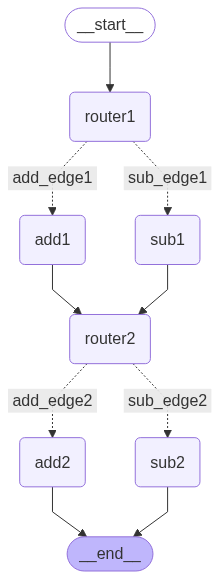

In [8]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png())) 

In [9]:
app.invoke(
    {
        'number1': 10,
        'number2': 5,
        'number3': 20,
        'number4': 15,
        'operation1': '+',
        'operation2': '-'
    }
)

{'number1': 10,
 'number2': 5,
 'number3': 20,
 'number4': 15,
 'operation1': '+',
 'operation2': '-',
 'final_number1': 15,
 'final_number2': 5}